In [2]:
import heapq
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib.colors as mcolors
import cv2.aruco as aruco
import math

### Initialization

In [4]:
maze_height = 390     # Maze height
maze_width = 450      # Maze width

###      Transform and converts a maze image to a matrix 

    Parameters:
    - image_path: Path to the input image.
    - start_image_path: Path to the start point template image.
    - goal_image_path: Path to the goal point template image.
    - transforming: Flag to enable or disable perspective transformation.
    - transformed_file_name: Name for the saved transformed image file.
    - maze_height: Desired height of the output matrix.
    - maze_width: Desired width of the output matrix.

    Returns:
    - A binary matrix representation of the maze (1 = wall, 0 = open path).
    - cartesian_start_position: Coordinates of the start position in Cartesian format.
    - cartesian_goal_position: Coordinates of the goal position in Cartesian format.

In [27]:
def transform_and_convert_image_to_matrix(image_path, start_image_path, goal_image_path,
                                          transforming=True, transformed_file_name='maze',
                                          maze_height=390, maze_width=450):
    # Step 1: Read and transform the image
    image = cv.imread(image_path)
    transformed_image_filename = f"transformed-{transformed_file_name}.png"

    if transforming:
        # Detect ArUco markers
        aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
        parameters = aruco.DetectorParameters()
        corners, ids, _ = aruco.detectMarkers(image, aruco_dict, parameters=parameters) 
    
        # Check if exactly four markers are detected
        if ids is not None and len(ids) == 4:
            src_points = np.zeros((4, 2), dtype=np.float32)
            width, height = int(maze_width), int(maze_height)
            destination_points = np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype=np.float32)
            
            # Map each marker to a source point
            for i, marker_id in enumerate(ids.flatten()):
                c0, c1, c2, c3 = corners[i][0]
                center_x = (c0[0] + c1[0] + c2[0] + c3[0]) / 4
                center_y = (c0[1] + c1[1] + c2[1] + c3[1]) / 4
                
                if marker_id == 0:  # Bottom Left
                    src_points[3] = [center_x, center_y]
                elif marker_id == 1:  # Top Left
                    src_points[0] = [center_x, center_y]
                elif marker_id == 2:  # Top Right
                    src_points[1] = [center_x, center_y]
                elif marker_id == 3:  # Bottom Right
                    src_points[2] = [center_x, center_y]
    
            # Apply perspective transformation
            perspective_matrix = cv.getPerspectiveTransform(src_points, destination_points)
            transformed_image = cv.warpPerspective(image, perspective_matrix, (width, height))
            cv.imwrite(transformed_image_filename, transformed_image)
        
        else:
            print("No markers detected, or incorrect number of markers")
            transformed_image = image
    else:
        transformed_image = image

    # Step 2: Template matching to find start and goal positions
    start_template = cv.imread(start_image_path)
    goal_template = cv.imread(goal_image_path)

    def find_template_position(main_image, template):
        main_gray = cv.cvtColor(main_image, cv.COLOR_BGR2GRAY)
        template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
        result = cv.matchTemplate(main_gray, template_gray, cv.TM_CCOEFF_NORMED)
        _, _, _, max_loc = cv.minMaxLoc(result)
        template_height, template_width = template_gray.shape
        center_x = max_loc[0] + template_width // 2
        center_y = max_loc[1] + template_height // 2
        return center_x, center_y

    start_position = find_template_position(transformed_image, start_template)
    goal_position = find_template_position(transformed_image, goal_template)

    # Step 3: First attempt at edge detection on the transformed image
    grayscale_image = cv.cvtColor(transformed_image, cv.COLOR_BGR2GRAY)
    blurred_image = cv.GaussianBlur(grayscale_image, (3, 3), 0)
    resized_image = cv.resize(blurred_image, (maze_width, maze_height))
    edges_detected = cv.Canny(image=resized_image, threshold1=45, threshold2=200)

    # Step 4: Mask the start and goal areas
    mask = np.ones(transformed_image.shape[:2], dtype="uint8") * 255
    def apply_mask(mask, point, template):
        template_height, template_width = template.shape[:2]
        padding = 4  # 4-pixel buffer around the template area
        top_left_x = max(point[0] - template_width // 2 - padding, 0)
        top_left_y = max(point[1] - template_height // 2 - padding, 0)
        bottom_right_x = min(point[0] + template_width // 2 + padding, mask.shape[1])
        bottom_right_y = min(point[1] + template_height // 2 + padding, mask.shape[0])
        cv.rectangle(mask, (top_left_x, top_left_y), (bottom_right_x, bottom_right_y), 0, -1)

    apply_mask(mask, start_position, start_template)
    apply_mask(mask, goal_position, goal_template)
    masked_image = cv.bitwise_and(edges_detected, edges_detected, mask=mask)
    
    # Step 5: Second edge detection on the masked image
    blurred_image = cv.GaussianBlur(masked_image, (5, 5), 0)
    blurred_image[blurred_image > 50] = 255
    edges_detected = cv.Canny(masked_image, threshold1=45, threshold2=200)
    
    # Convert edges to binary format (1 for edge, 0 for non-edge)
    edges_detected[edges_detected > 0] = 1 

    # Calculate Cartesian positions for start and goal points
    cartesian_start_position = (start_position[0], maze_height - start_position[1])
    cartesian_goal_position = (goal_position[0], maze_height - goal_position[1])
    
    # Return binary edge matrix and Cartesian coordinates
    return np.array(np.flip(edges_detected, axis=0)), cartesian_start_position, cartesian_goal_position

### Function to show matrix (invert in y axis , because we want to see everything based on cartesion)

In [30]:
def imshow_maze_matrix(maze):
    plt.imshow(maze)
    plt.gca().invert_yaxis()

### Extract robot coordinates from log file

    Parameters:
    - file_path: path to the file containing movement data.
    - start: tuple of (x, y) starting coordinates to adjust each movement relative to.
    
    Returns:
    - x_coords: list of adjusted x-coordinates.
    - y_coords: list of adjusted y-coordinates.

In [34]:
def robot_movement_on_maze(file_path, start):
    x_coords = []
    y_coords = []

    # Read the data from the file
    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()  # Remove any leading/trailing whitespace
            
            if not line:  # Skip empty lines
                continue
            
            # Split the line by commas
            parts = line.split(',')
            
            if len(parts) > 1:  # Ensure there are at least two parts for x and y
                try:
                    # Extract and adjust x and y values based on start position
                    x_value = float(parts[0].split('=')[1]) + start[0]
                    y_value = float(parts[1].split('=')[1]) + start[1]
                    
                    # Append the values to the lists
                    x_coords.append(x_value)
                    y_coords.append(y_value)
                except (IndexError, ValueError) as e:
                    print(f"Error processing line: {line}")
                    print(e)
    
    return x_coords, y_coords

## Example:

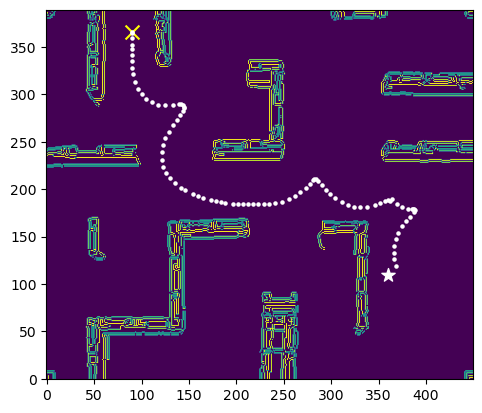

In [43]:
maze_matrix, start, goal = transform_and_convert_image_to_matrix(image_path='img/robot_game_with_se.jpg', start_image_path='img/start_point.png',
                                                                 goal_image_path='img/end_point.png', transforming=True,
                                                                 transformed_file_name='final_maze',
                                                                 maze_height=maze_height, maze_width=maze_width)
robot_movement = robot_movement_on_maze('robot_movement_round1.txt', start)
x_coords, y_coords = robot_movement

imshow_maze_matrix(maze_matrix)
plt.scatter([start[0]], [start[1]], color="yellow", s=100, marker='x')
plt.scatter([goal[0]], [goal[1]], color="white", s=100, marker='*')
plt.scatter(x_coords, y_coords, color="white", s=5, marker='o')

###      Uses the A* algorithm to find a path through the maze from start to goal, returning the path and movement directions.”

    Parameters:
    - maze: 2D list representing the maze grid (0 = open path, 1 = wall).
    - start: tuple (x, y) of the starting position.
    - goal: tuple (x, y) of the goal position.
    - buffer_size: distance in cells to maintain from walls.
    
    Returns:
    - path: list of coordinates from start to goal, or None if no path exists.
    - directions: list of movement directions to follow the path.

In [47]:
def maze_astar_solver(maze, start, goal, buffer_size=1):

    # Calculate Manhattan distance
    def manhattan_distance(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    # Check if the current position is valid within the maze
    def is_valid(maze, pos, buffer_size):
        rows, cols = len(maze), len(maze[0])
        
        #--------------------------------------------------------------------------------#
        #-----------------------------IMPORTANT------------------------------------------#
        #--------------------------------------------------------------------------------#
        col, row = pos # pos is cartesian: always keep this one 
        #--------------------------------------------------------------------------------#
        #--------------------------------------------------------------------------------#
        #--------------------------------------------------------------------------------#
        
        # Check if the position is within bounds and not a wall
        if not (0 <= row < rows and 0 <= col < cols) or maze[row][col] != 0:
            return False
        
        # Check surrounding positions to ensure buffer from walls
        for r_offset in range(-buffer_size, buffer_size + 1):
            for c_offset in range(-buffer_size, buffer_size + 1):
                check_row, check_col = row + r_offset, col + c_offset
                if 0 <= check_row < rows and 0 <= check_col < cols:
                    if maze[check_row][check_col] == 1:
                        return False
        return True

    # Reconstruct the path from the goal back to the start using came_from
    def reconstruct_path(came_from, current):
        path, directions = [], []
        while current in came_from:
            previous, direction = came_from[current]
            path.append(current)
            directions.append(direction)
            current = previous
        path.reverse()
        directions.reverse()
        return path, directions

    # Validate start and goal points
    if not is_valid(maze, start, buffer_size):
        return "Start point is invalid."
    if not is_valid(maze, goal, buffer_size):
        return "Goal point is invalid."

    # Direction mapping
    directions_map = {"right": (1, 0), "down": (0, -1), "left": (-1, 0), "up": (0, 1)}
    all_directions = ["right", "down", "left", "up"]

    open_list = [(0, start)]  # Open list for A* storing nodes to explore with their f-score
    g_score = {start: 0}  # Dictionary for g-scores, tracking the cost to reach each node
    came_from = {}  # Tracks each node’s predecessor and the direction taken to reach it

    # A* search main loop
    while open_list:
        _, current = heapq.heappop(open_list)  # Pop node with the lowest f-score
        
        if current == goal:  # Check if the goal has been reached
            return reconstruct_path(came_from, current)
        
        for direction in all_directions:  # Explore all possible directions
            move = directions_map[direction]
            neighbor = (current[0] + move[0], current[1] + move[1])  # Determine the neighbor’s position
            
            # Validate neighbor and compute new g-score
            if is_valid(maze, neighbor, buffer_size): 
                new_g_score = g_score[current] + 1  # Increment g-score for the next step
                
                # If this path to the neighbor is better or unvisited, update scores and path
                if neighbor not in g_score or new_g_score < g_score[neighbor]: 
                    g_score[neighbor] = new_g_score
                    f_score = new_g_score + manhattan_distance(neighbor, goal)
                    heapq.heappush(open_list, (f_score, neighbor))  # Push neighbor with its f-score
                    came_from[neighbor] = (current, direction)  # Track path and direction

    return None

## Example

In [50]:
solved = maze_astar_solver(maze_matrix, start, goal, 20)
path, directions = solved

In [51]:
# print("Full path:", *path, sep='\n')
# print("Directions:", *directions, sep='\n')

## Transform path to origin coordinates

In [55]:
def transform_path_to_origin(path):
    if not path:
        return []
    start_x, start_y = path[0]
    transformed_path = [(x - start_x, y - start_y) for x, y in path]
    return transformed_path

In [57]:
translated_path_form_00 = transform_path_to_origin(path)
# print("Path from (0,0):", *translated_path_form_00, sep='\n')

### Summarizes consecutive movements in the same direction and counts the number of consecutive moves.

    Parameters:
    - directions: list of movement directions (e.g., ["up", "down", "right", "lwft"]).
    
    Returns:
    - A list of dictionaries, each with 'direction' and 'cm' keys, representing the direction
      and count of consecutive moves.

In [61]:
######      Summarizes consecutive movements in the same direction and counts the number of consecutive moves.
def summarize_path(directions):

    if not directions:
        return []

    summarized_movements = []  # Store summarized movements
    current_index = 0

    # Initialize with the first movement
    current_movement = {
        "direction": directions[0],
        "cm": 1
    }
    summarized_movements.append(current_movement)

    # Loop through the directions to find consecutive movements
    for i in range(1, len(directions)):
        if directions[i] == current_movement["direction"]:
            # Increment count if the direction is the same
            summarized_movements[current_index]["cm"] += 1
        else:
            # Start a new movement entry if the direction changes
            current_movement = {
                "direction": directions[i],
                "cm": 1
            }
            current_index += 1
            summarized_movements.append(current_movement)

    return summarized_movements


## Example:

In [64]:
#example:
summarized_path = summarize_path(directions)
print("number of movement: ", len(summarized_path))
print("\nSummerized Path: ",*summarized_path, sep='\n')

number of movement:  25

Summerized Path: 
{'direction': 'down', 'cm': 99}
{'direction': 'right', 'cm': 26}
{'direction': 'down', 'cm': 12}
{'direction': 'right', 'cm': 1}
{'direction': 'down', 'cm': 2}
{'direction': 'right', 'cm': 1}
{'direction': 'down', 'cm': 3}
{'direction': 'right', 'cm': 1}
{'direction': 'down', 'cm': 2}
{'direction': 'right', 'cm': 1}
{'direction': 'down', 'cm': 58}
{'direction': 'right', 'cm': 110}
{'direction': 'down', 'cm': 1}
{'direction': 'right', 'cm': 3}
{'direction': 'down', 'cm': 2}
{'direction': 'right', 'cm': 124}
{'direction': 'down', 'cm': 1}
{'direction': 'right', 'cm': 2}
{'direction': 'down', 'cm': 2}
{'direction': 'right', 'cm': 1}
{'direction': 'down', 'cm': 25}
{'direction': 'right', 'cm': 1}
{'direction': 'down', 'cm': 47}
{'direction': 'left', 'cm': 1}
{'direction': 'down', 'cm': 2}


## Merge Small Moves into Larger Movement Chunks and Generate Cleaned Path

    Parameters:
    moves: list of movements with direction and count of moves in that direction.
    start: starting coordinate for the path.
    move_size_limit: minimum size to consider a move as large.
    angle: direction preference.

    Returns:
    - grouped_chunks: dictionary of consolidated movements.
    - clean_full_paths: list of coordinates representing the cleaned path.
    - clean_directions: list of directions for each move in the path.

In [68]:
######      clean up summerized path by merging small moves into prev or next large move
def clean_up_path(moves, start=start,  move_size_limit=15,angle='up'):
    
    grouped_chunks = {}  # Store movement chunks
    current_chunk_key = 0  # Key to identify each chunk
    
    # Group moves into chunks
    for move in moves:
        if move["cm"] > move_size_limit:
            # Create a new chunk for large moves
            current_chunk_key += 1 
            grouped_chunks[current_chunk_key] = {move["direction"]: move["cm"]}
        else:
            # Add small moves to the current chunk
            if move["direction"] in grouped_chunks.get(current_chunk_key, {}):
                grouped_chunks[current_chunk_key][move["direction"]] += move["cm"]
            else:
                grouped_chunks.setdefault(current_chunk_key, {})[move["direction"]] = move["cm"]

    # Merge small moves with neighboring chunks in the same direction
    for chunk_key, current_chunk in grouped_chunks.items():
        next_chunk = grouped_chunks.get(chunk_key + 1, {})
        
        for direction in ["left", "right", "down", "up"]:
            if (
                direction in current_chunk 
                and current_chunk[direction] < move_size_limit 
                and direction in next_chunk 
                and next_chunk[direction] >= move_size_limit
            ):
                next_chunk[direction] += current_chunk[direction]
                current_chunk[direction] = 0  # Mark current chunk's move for removal

    # Remove zeroed moves from chunks
    for chunk_key, current_chunk in grouped_chunks.items():
        for direction in ["left", "right", "down", "up"]:
            if current_chunk.get(direction) == 0:
                current_chunk.pop(direction)
    
    # Further merge small moves with the next chunk if the direction exists in both
    for chunk_key, current_chunk in grouped_chunks.items():
        next_chunk = grouped_chunks.get(chunk_key + 1, {})
        for direction in list(current_chunk.keys()):
            if direction in next_chunk:
                next_chunk[direction] += current_chunk[direction]
                current_chunk.pop(direction)
    
    # Remove empty chunks
    grouped_chunks = {key: value for key, value in grouped_chunks.items() if value}

    # Generate the cleaned full path based on grouped movements
    clean_full_paths = [start]
    for move in grouped_chunks.values():
        last_x, last_y = clean_full_paths[-1]
        
        if "left" in move:
            cm = move["left"]
            new_xs = list(np.arange(last_x - 1, last_x - cm - 1, -1))
            clean_full_paths += [(x, last_y) for x in new_xs]
        
        if "right" in move:
            cm = move["right"]
            new_xs = list(np.arange(last_x + 1, last_x + cm + 1, 1))
            clean_full_paths += [(x, last_y) for x in new_xs]
        
        if "down" in move:
            cm = move["down"]
            new_ys = list(np.arange(last_y - 1, last_y - cm - 1, -1))
            clean_full_paths += [(last_x, y) for y in new_ys]
        
        if "up" in move:
            cm = move["up"]
            new_ys = list(np.arange(last_y + 1, last_y + cm + 1, 1))
            clean_full_paths += [(last_x, y) for y in new_ys]

    # Generate direction list for each move in the cleaned path
    clean_directions = []
    for move in grouped_chunks.values():
        dir = list(move.keys())[0]
        clean_directions += [dir] * move[dir]
    clean_directions = [clean_directions[0]] + clean_directions

    return grouped_chunks, clean_full_paths, clean_directions 

## Example:

In [71]:
#Example for virtual robot:
clean_result = clean_up_path(summarized_path,start,15)
cleaned_path, clean_full_path, clean_direction = clean_result

In [73]:
#Example for cleaning path with start point at (0, 0):
clean_result_from_00 = clean_up_path(summarized_path,(0,0),15)
cleaned_path_from_00, clean_full_path_from_00, clean_direction_from_00 = clean_result_from_00

In [75]:
# print("\nCleaned full Path: ",*clean_full_path, sep='\n')
# print("\nCleaned full Path from 0,0: ",*clean_full_path_from_00, sep='\n')
print("\nCleaned Path: ",cleaned_path)
# print("\nCleaned Path  from 0,0: ", cleaned_path_from_00)
# print("\nCleaned directions: ", *clean_direction, sep="\n")
# print("\nCleaned directions from 0,0: ", *clean_direction_from_00, sep='\n')
# print("\nGoal based on start from 0,0: ", clean_full_path_from_00[-1])


Cleaned Path:  {2: {'right': 30}, 4: {'down': 179}, 6: {'right': 241}, 7: {'down': 77, 'left': 1}}


### Visualize A* Path, Summarized Path, and Cleaned Path on Maze

    - path: list of (x, y) coordinates representing the path.
    - directions: list of movement directions along the path.
    - start_point: starting coordinates for the path.
    - maze_grid: 2D binary matrix of the maze (0 = open path, 1 = wall).
    - output_image_filename: filename to save the output image.
    - fig_size: figure size for the plot.
    - show_maze: whether to display the maze grid.
    - print_path: print the path coordinates.
    - print_directions: print movement directions.
    - show_summarized_path: plot the summarized path.
    - show_cleaned_path: plot the cleaned path.
    - print_summarized_path_info: print summarized path details.
    - print_cleaned_path_info: print cleaned path details.

In [79]:
######      Visualize A* Path, Summarized Path, and Cleaned Path on Maze
def visualize_paths(path, directions, start_point, maze_grid, 
                    output_image_filename, fig_size=10, show_maze=True,
                    print_path=True, print_directions=True, 
                    show_summarized_path=True, show_cleaned_path=True, 
                    print_summarized_path_info=True, print_cleaned_path_info=True):
    #
    # show_maze: show the original maze.
    # print_path: print the path.
    # print_directions: print the movement directions.
    # show_summarized_path: plot the summarized path.
    # show_cleaned_path:plot the cleaned path.
    # ptint_summarized_path_info: print the summarized path information.
    # print_cleaned_path_info: print the cleaned path information.
    #

    output_image_filename = f"maze-map-path-{output_image_filename}.png"
    
    # if path found
    if path:

        path_coordinates= path
        move_directions = directions

        # get X and Y coordinates from path
        path_x_coords = [coord[0] for coord in path_coordinates]
        path_y_coords = [coord[1] for coord in path_coordinates]

        # call summerize_path funtion to get summerized path
        # summarized_moves = summarize_path(move_directions, path_coordinates)


        summarized_moves = summarize_path(move_directions)

        initial_x, initial_y = start_point[0], start_point[1]
        x_movement, y_movement = [initial_x], [initial_y]

        # adjust X and Y coordinates based on the movement direction and distance ('cm') from summerized list
        for movement in summarized_moves:
            
            if movement["direction"] == "left":
                x_movement.append(x_movement[-1] - movement["cm"])  # Move left
                y_movement.append(y_movement[-1])
            if movement["direction"] == "right":
                x_movement.append(x_movement[-1] + movement["cm"])  # Move right
                y_movement.append(y_movement[-1])
            if movement["direction"] == "down":
                x_movement.append(x_movement[-1])
                y_movement.append(y_movement[-1] - movement["cm"])  # Move down
            if movement["direction"] == "up":
                x_movement.append(x_movement[-1])
                y_movement.append(y_movement[-1] + movement["cm"])  # Move up

        # clean up the summerized path (remove samll movement and add them to big moves)
        cleaned_path_result = clean_up_path(summarized_moves, start_point)
        cleaned_path,_,_ = cleaned_path_result
        cleaned_x_movement, cleaned_y_movement = [initial_x], [initial_y]

        # adjust X and Y coordinates based on the movement direction for cleaned up list
        for key in sorted(list(cleaned_path.keys())):
            movement = cleaned_path[key]

            if "left" in movement:
                cleaned_x_movement.append(cleaned_x_movement[-1] - movement["left"])  # Move left
                cleaned_y_movement.append(cleaned_y_movement[-1])
            if "right" in movement:
                cleaned_x_movement.append(cleaned_x_movement[-1] + movement["right"])  # Move right
                cleaned_y_movement.append(cleaned_y_movement[-1])
            if "down" in movement:
                cleaned_x_movement.append(cleaned_x_movement[-1])
                cleaned_y_movement.append(cleaned_y_movement[-1] - movement["down"])  # Move down
            if "up" in movement:
                cleaned_x_movement.append(cleaned_x_movement[-1])
                cleaned_y_movement.append(cleaned_y_movement[-1] + movement["up"])  # Move up

        # Showing and Ploting:
        plt.figure(figsize=(fig_size,fig_size)) 
        if show_maze:
            imshow_maze_matrix(maze_grid)  # Display the maze
            plt.scatter([start[0]], [start[1]], color="yellow", s=100, marker='x')
            plt.scatter([goal[0]], [goal[1]], color="blue", s=100, marker='*')
            
        if print_directions:
            print("\nPath Directions:", *move_directions, sep='\n')

        if print_summarized_path_info:
            print("Summarized Path Movements:", *summarized_moves, sep='\n')

        if print_cleaned_path_info:
            print("\nNumber of movements in cleaned path: ", len(cleaned_path))
            print("\nCleaned Path Movements:", *cleaned_path.values(), sep='\n')

        if print_path:
            plt.scatter(path_y_coords, path_x_coords, s=10, color="r")  # Plot the path

        if show_summarized_path:
            plt.plot(x_movement, y_movement, color='white', linestyle='dashed') #Plot the summerized Path

        if show_cleaned_path:
            plt.plot(cleaned_x_movement, cleaned_y_movement, color='yellow', linewidth=7, alpha=0.5) #Plot the cleaned Path
            
           
        plt.savefig(output_image_filename)
        plt.show()  # Display the image

    else:
        print("There is no path from the start to the goal.")

## Example:

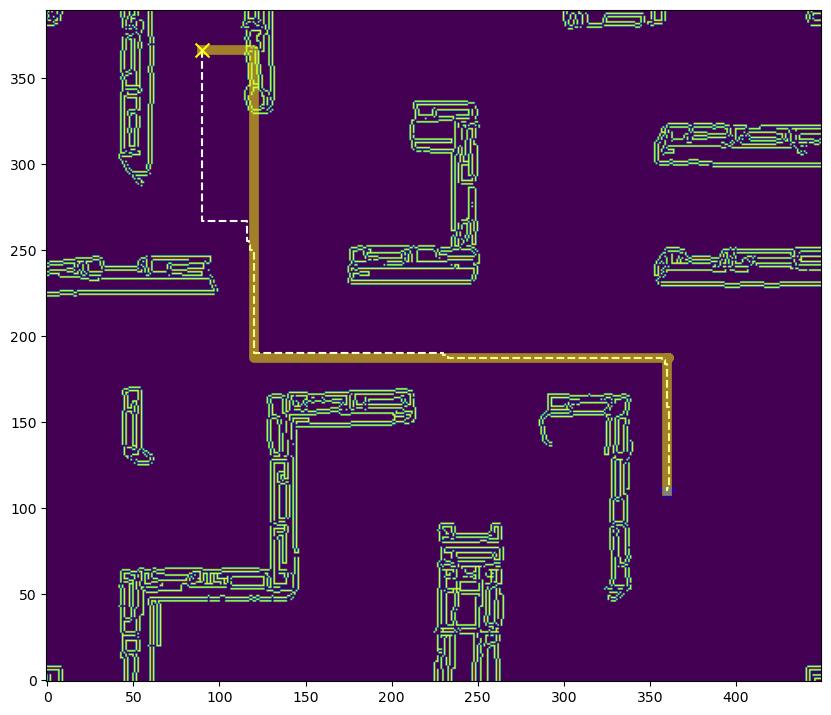

In [82]:
#example:
visualize_paths(path=path, directions=directions, start_point=start,
                maze_grid=maze_matrix, output_image_filename='maze_robot',
                fig_size=10, show_maze=True,
                print_path=False, print_directions=False, 
                show_summarized_path=True, show_cleaned_path=True, 
                print_summarized_path_info=False, print_cleaned_path_info=False)

## Fit polynomial calibration curve for censor cata

    Parameters:
    - sensor_values: list of sensor readings.
    - actual_distances: list of actual distances corresponding to sensor readings.
    - sensor_id: unique identifier for the sensor.
    - calibration_coefficients: dictionary to store or update calibration coefficients for sensors.
    - polynomial_degree: degree of the polynomial for fitting.
    
    Returns:
    - calibration_coefficients: updated dictionary with calibration data for the sensor.

In [86]:
######      use polynomial curve to the sensor values and actual distances and returns calibration coefficients.
def fit_calibration_curve(sensor_values, actual_distances, sensor_id, calibration_coefficients=None, polynomial_degree=1):

    # check if calibration data is not exist, make new one
    if calibration_coefficients is None:
        calibration_coefficients = {}
    
    # Fit polynomial curve and retrieve coefficients
    coefficients = np.polyfit(sensor_values, actual_distances, polynomial_degree)
    
    # Store the coefficients for this sensor
    calibration_coefficients[sensor_id] = coefficients

    return calibration_coefficients

## Calculate calibrated cistance from sensor reading

    Parameters:
    - sensor_reading_tuple: tuple containing the sensor reading and sensor ID.
    - calibration_coefficients: dictionary with calibration coefficients for sensors.
    
    Returns:
    - Calibrated distance for the sensor reading.

In [90]:
#calculate calibrated data
def calculate_calibrated_distance(sensor_reading_tuple, calibration_coefficients):

    # Separate sensor reading and sensor ID
    sensor_reading, sensor_id = sensor_reading_tuple
    
    # Check if sensor is calibrated; if so, calculate distance
    if sensor_id in calibration_coefficients:
        coefficients = calibration_coefficients[sensor_id]
        return np.polyval(coefficients, sensor_reading)
    else:
        raise ValueError(f"No calibration data found for sensor {sensor_id}.")

## Visualize calibration data for selected sensors”

    Parameters:
    - sensor_list: dictionary where keys are sensor IDs and values are lists of sensor readings.
    - actual_distances: list of actual distances corresponding to sensor readings.
    - selected_sensors: list of sensor IDs to visualize.
    
    Displays:
    - A plot of actual distance versus sensor values for the selected sensors.

In [94]:
######      visulizing sensor data for spesific sensors    
def visualize_sensor_data(sensor_list, actual_distances, selected_sensors):
    
    # loop through the selected sensors and plot each one
    for sensor_id in selected_sensors:
        sensor_values = sensor_list[sensor_id]
        plt.plot(actual_distances, sensor_values, 'o-', label=f"Sensor {sensor_id}")
    
    plt.title(f"Sensor Calibration Curves for Sensors {', '.join(map(str, selected_sensors))}")
    plt.xlabel("Actual Distance (cm)")
    plt.ylabel("Sensor Value")
    plt.ylim(0,500)
    plt.grid(True)
    plt.legend()
    plt.show()

## Example:

In [97]:
#example:

distances_cm = [1, 2, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]
sensors = [
    np.array([3744, 3755, 2716, 860, 335, 152, 100, 66, 44, 32, 23, 19]),  # left_obstacle_sensor0
    np.array([3392, 1626, 662, 226, 55, 22, 17, 18, 16, 17, 14, 11]),      # left_obstacle_sensor1
    np.array([3737, 3664, 1301, 367, 273, 216, 150, 115, 90, 71, 59, 52]), # front_obstacle_sensor2
    np.array([3663, 3711, 2992, 947, 389, 207, 119, 78, 58, 46, 38, 31]),  # front_obstacle_sensor3
    np.array([3281, 2789, 2166, 660, 274, 144, 86, 66, 53, 46, 38, 38]),   # front_obstacle_sensor4
    np.array([1686, 1746, 746, 178, 66, 33, 20, 11, 9, 7, 2, 5]),          # right_obstacle_sensor5
    np.array([3819, 3796, 3532, 947, 354, 170, 97, 58, 39, 30, 23, 19])    # right_obstacle_sensor6
]

In [99]:
#example:

calibration_data = {}

for i, sensor_data in enumerate(sensors):
    calibration_data = fit_calibration_curve(sensor_data, distances_cm, sensor_id=i, calibration_coefficients=calibration_data)
    
sensor_reading = (860, 0) #first element is sensor value, second one is sensor id
calibrated_distance = calculate_calibrated_distance(sensor_reading, calibration_coefficients=calibration_data)

print(f'Calibrated distance for sensor 0: {calibrated_distance} cm')

Calibrated distance for sensor 0: 19.496192912844215 cm


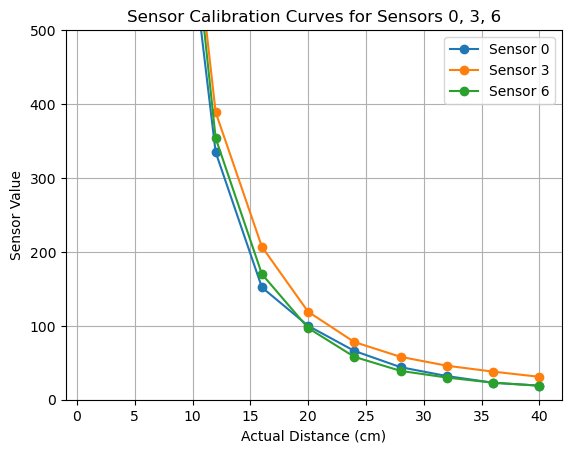

In [101]:
#example:
visualize_sensor_data(sensors, distances_cm, [0, 3, 6]) 

## Generate and visualize directional filters

    Parameters:
    - template_size: size of the square filter template.
    - filter_width: width of the filter in each direction.
    - filter_length: length of the filter in each direction.
    
    Displays:
    - A figure with four subplots, each showing a directional filter.

In [105]:
def generate_and_visualize_filters(template_size=80, filter_width=10, filter_length=40):
   
    # Initialize template and calculate midpoint
    mid_point_idx = template_size // 2
    filter_template = np.zeros((template_size, template_size))

    # Create filters for each direction by copying the template and modifying specific areas
    filter_up = filter_template.copy()
    filter_up[mid_point_idx - filter_length: mid_point_idx,
              mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width] = 1

    filter_down = filter_template.copy()
    filter_down[mid_point_idx: mid_point_idx + filter_length,
                mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width] = 1

    filter_left = filter_template.copy()
    filter_left[mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width,
                mid_point_idx - filter_length: mid_point_idx] = 1

    filter_right = filter_template.copy()
    filter_right[mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width,
                 mid_point_idx: mid_point_idx + filter_length] = 1

    # Visualize the filters in a single row of subplots
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(filter_up)
    plt.title("Up")
    
    plt.subplot(1, 4, 2)
    plt.imshow(filter_down)
    plt.title("Down")
    
    plt.subplot(1, 4, 3)
    plt.imshow(filter_right)
    plt.title("Right")
    
    plt.subplot(1, 4, 4)
    plt.imshow(filter_left)
    plt.title("Left")
    
    plt.show()

## Example:

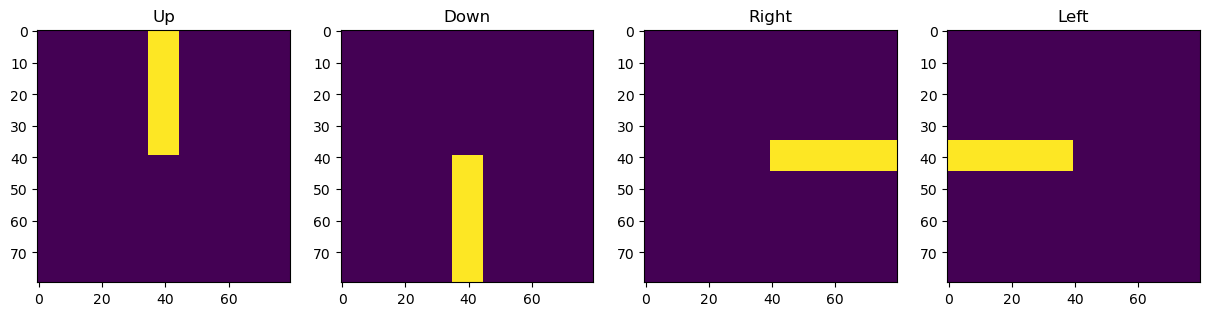

In [108]:
#example:
generate_and_visualize_filters()

## Detect walls along a aath using directional filters

    Parameters:
    - maze: 2D binary matrix representing the maze (0 = open path, 1 = wall).
    - path: list of (x, y) coordinates representing the A* path through the maze.
    - filter_size: length of each directional filter.
    - directions: list of directions ('up', 'down', 'left', 'right') along the path.
    
    Returns:
    - wall_statuses: list of dictionaries with wall presence status (1 if wall present, 0 otherwise)
      for 'front', 'left', and 'right' relative to the current direction.

In [117]:
######      wall detection filtering by convolv for each position in a-star path
def wall_detection_filtering(maze, path, filter_size, directions):
    
     # Template parameters
    template_size = 80
    mid_point_idx = template_size // 2
    filter_template = np.zeros((template_size, template_size))
    filter_width = 10
    filter_length = filter_size
    
    # Create directional filters
    filter_up = filter_template.copy()
    filter_up[mid_point_idx - filter_length: mid_point_idx,
              mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width] = 1
    
    filter_down = filter_template.copy()
    filter_down[mid_point_idx: mid_point_idx + filter_length,
                mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width] = 1
    
    filter_left = filter_template.copy()
    filter_left[mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width,
                mid_point_idx - filter_length: mid_point_idx] = 1
    
    filter_right = filter_template.copy()
    filter_right[mid_point_idx - filter_width // 2: mid_point_idx - filter_width // 2 + filter_width,
                 mid_point_idx: mid_point_idx + filter_length] = 1

    # Apply 2D convolution for each direction
    up_walls = sp.signal.convolve2d(maze, filter_up, "same")
    down_walls = sp.signal.convolve2d(maze, filter_down, "same")
    right_walls = sp.signal.convolve2d(maze, np.flip(filter_right, axis=1), "same")
    left_walls = sp.signal.convolve2d(maze, np.flip(filter_left, axis=1), "same")

    # Determine wall presence along the path for each direction
    up_wall_count = np.array([up_walls[y, x] for x, y in path])
    up_wall_count[up_wall_count > 0] = 1

    down_wall_count = np.array([down_walls[y, x] for x, y in path])
    down_wall_count[down_wall_count > 0] = 1

    right_wall_count = np.array([right_walls[y, x] for x, y in path])
    right_wall_count[right_wall_count > 0] = 1

    left_wall_count = np.array([left_walls[y, x] for x, y in path])
    left_wall_count[left_wall_count > 0] = 1

    # Initialize list to store wall statuses by direction and position
    wall_statuses = []

    # Define direction mapping for front, left, and right relative positions
    direction_mapping = {
        'up':    {'front': up_wall_count, 'left': left_wall_count, 'right': right_wall_count},
        'down':  {'front': down_wall_count, 'left': right_wall_count, 'right': left_wall_count},
        'left':  {'front': left_wall_count, 'left': down_wall_count, 'right': up_wall_count}, 
        'right': {'front': right_wall_count, 'left': up_wall_count, 'right': down_wall_count},
    }

    # Loop through the path to determine wall status for each position
    for idx, (direction, position) in enumerate(zip(directions, path)):
        mapping = direction_mapping[direction]
        
        wall_statuses.append({
            "direction": direction,
            "position": position,
            "front_wall": int(mapping['front'][idx]),
            "left_wall": int(mapping['left'][idx]),
            "right_wall": int(mapping['right'][idx])
        })
        
    return wall_statuses

## Example:

In [120]:
#example:
wall_status = wall_detection_filtering(maze_matrix, path, 40, directions)
# wall_status
for item in wall_status[:10]: #just print first 10
    print(item)

{'direction': 'down', 'position': (90, 365), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 364), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 363), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 362), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 361), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 360), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 359), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 358), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 357), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}
{'direction': 'down', 'position': (90, 356), 'front_wall': 0, 'left_wall': 1, 'right_wall': 1}


## Plot a path based on wall conditions

    Parameters:
    - maze: 2D binary matrix representing the maze (0 = open path, 1 = wall).
    - wall_statuses: list of dictionaries with wall presence status ('front_wall', 'left_wall', 'right_wall')
                     for each position along the path.
    
    Displays:
    - A plot of the maze with each path position colored according to wall presence.

In [124]:
######      plot path status based on wall condistion
def plot_wall_conditions(maze, wall_statuses):
    
    # Define color map for wall configurations
    color_map = {
        (0, 0, 0): 'white',     # No walls
        (1, 0, 0): 'red',       # Wall only in front
        (0, 1, 0): 'green',     # Wall only to the right
        (0, 0, 1): 'blue',      # Wall only to the left
        (1, 1, 0): 'yellow',    # Walls in front and right
        (1, 0, 1): 'orange',    # Walls in front and left
        (0, 1, 1): 'purple',    # Walls to the left and right
        (1, 1, 1): 'black'      # Walls on all sides
    }
    
    # Plot the maze with the path overlaid
    plt.figure(figsize=(15, 15))
    imshow_maze_matrix(maze)
    
    # Plot each position in the path with the corresponding wall condition color
    for status in wall_statuses:
        x, y = status['position']
        
        # Determine wall presence
        wall_condition = (
            status['front_wall'],
            status['right_wall'],
            status['left_wall']
        )
        
        # Retrieve the color for the wall condition or default to gray
        color = color_map.get(wall_condition, 'gray')
        plt.scatter(x, y, color=color, s=10, axes=plt.gca())


## Example:

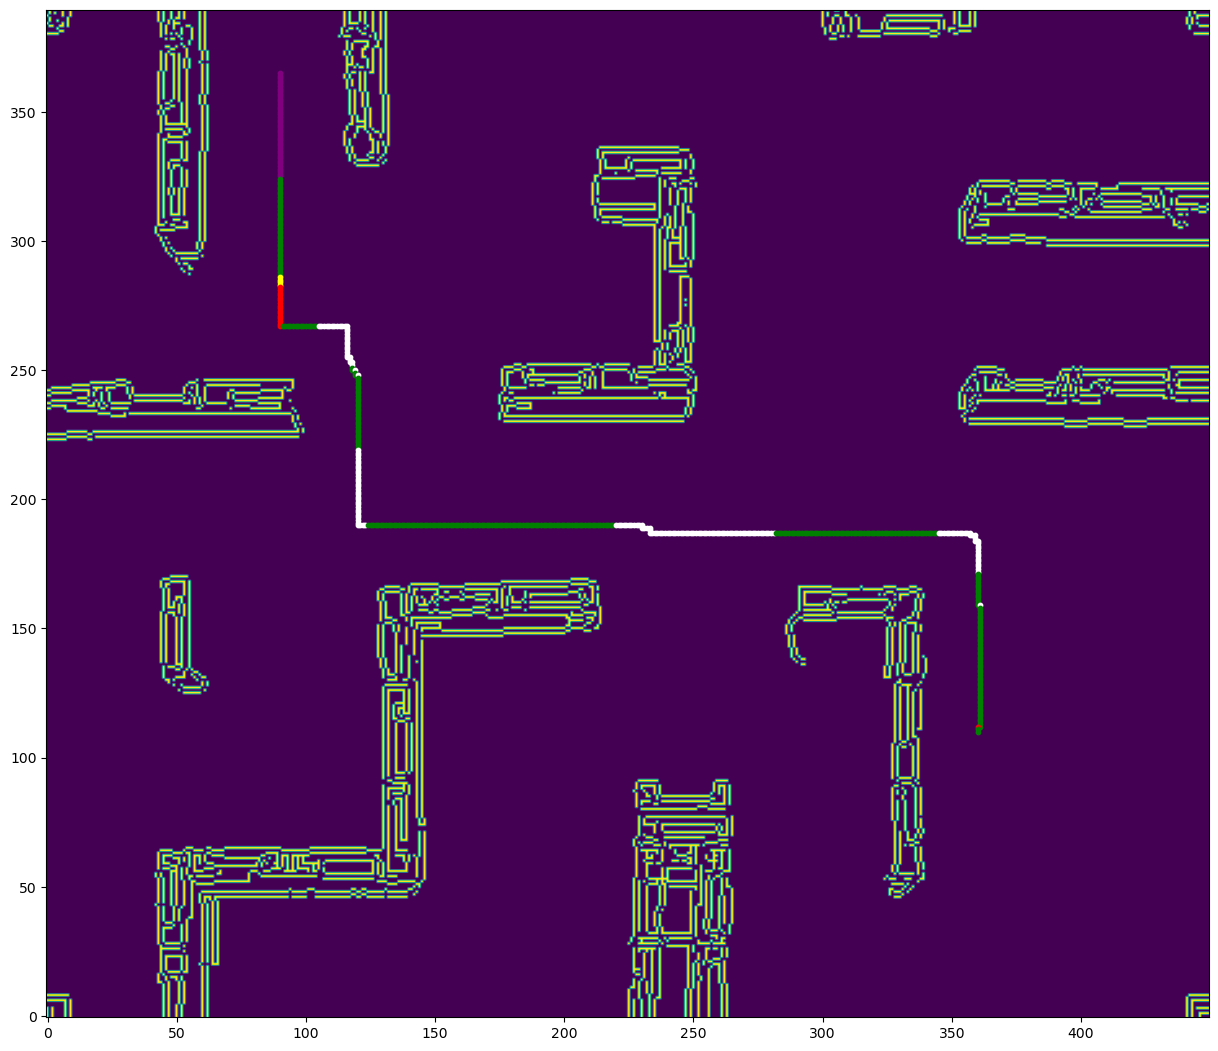

In [127]:
plot_wall_conditions(maze_matrix, wall_status)

## Simulated virtual robot with sensor and movement capabilities

In [130]:
######      virtual robot 
class VirtualRobot:
    def __init__(self, maze, start, goal, 
                 astar_path, astar_path_bandwidth, 
                 sensor_range=1):
        # initializeation
        self.start_x_actual = start[0]  
        self.start_y_actual = start[1]
        self.end_x_actual = goal[0]      
        self.end_y_actual = goal[1]
        self.astar_path = astar_path
        self.astar_path_bandwidth = astar_path_bandwidth
        self.maze = np.array(maze)
        self.sensor_range = sensor_range
        
        # start conditons
        self.x = start[0]  
        self.y = start[1]
        self.heading = 90 # facing right (0 degrees)
        self.history = [(self.x, self.y, self.heading)]  # Log initial position and heading

    # simulate reading sensors for front, left, and right positions
    def read_sensors(self):
        front = self._check_sensor(self.heading)
        left = self._check_sensor((self.heading + 65) % 360)
        right = self._check_sensor((self.heading - 65) % 360)
        return {'front': front, 'left': left, 'right': right}
        
    # calculate and return the distance to the nearest obstacle in the given angle
    def _check_sensor(self, angle):
        
        rad_angle = np.radians(angle)
        for distance in np.arange(0.5, self.sensor_range + 0.5, 0.5):
            check_x = int(round(self.x + distance * np.cos(rad_angle)))
            check_y = int(round(self.y + distance * np.sin(rad_angle)))
            if not self._within_bounds(int(check_x), int(check_y)) or self.maze[check_y][check_x] == 1:
                return distance
        return 1000  # large value indicating no obstacle
        
    # Ensure the given position is within the maze's boundaries
    def _within_bounds(self, x, y):
        return 0 <= x < self.maze.shape[1] and 0 <= y < self.maze.shape[0]

    # move robot forward if there is no obstacle within the specified distance
    def move(self, distance=1):
        
        if self._check_sensor(self.heading) >= distance:
            rad_heading = np.radians(self.heading)
            self.x = self.x + distance * np.cos(rad_heading)
            self.y = self.y + distance * np.sin(rad_heading)
            self.history.append((self.x, self.y, self.heading))  # log the movement in robot history

    # rotate the robot by a specified angle
    def rotate(self, angle):
        # Rotate the robot by a specified angle
        self.heading = (self.heading + angle) % 360

    def get_history(self):
        return self.history

## Check if robot is within a path boundaries

    Parameters:
    - robot: the VirtualRobot instance.
    - path: list of (x, y) coordinates representing the A* path.
    - distance: distance to check from the robot's current position.
    - angle: angle for the direction to check from the robot's current position.
    
    Returns:
    - True if the robot's next position is within the path boundary; False otherwise.

In [134]:
######      check if the robot is within the boundaries of path
def is_within_astar_boundaries(robot, path, distance, angle): 
    
    ideal_path = path
    path_bandwidth = robot.astar_path_bandwidth
    check_x = int(round(robot.x + distance * np.cos(np.radians(angle))))
    check_y = int(round(robot.y + distance * np.sin(np.radians(angle))))
    
    # Calculate distance to each point on the path
    for x1, y1 in ideal_path:
        euclidean_distance = math.sqrt((check_x - x1) ** 2 + (check_y - y1) ** 2)
        if euclidean_distance <= path_bandwidth:
            return True  # Position is within path boundary
    
    return False  # Position is outside the path boundary

## Check if Position is Within Distance to Goal

    Parameters:
    - x1, y1: coordinates of the current position.
    - x2, y2: coordinates of the goal position.
    - threshold: distance threshold for proximity to the goal.
    
    Returns:
    - True if within threshold distance, False otherwise.

In [156]:
# Checks if a robot position(x1, y1) is within a certain distance (threshold) to a goal (x2, y2)
def is_within_distance_to_goal(x1, y1, x2, y2, threshold):
    return True if np.abs((x1 - x2) ** 2 + (y1 - y2) ** 2) < threshold else False

## Move robot towards goal with rotation and movement

    Parameters:
    - my_robot: instance of the VirtualRobot class.
    - goal: tuple representing the (x, y) coordinates of the goal position.

In [160]:
# move to goal 
def move_robot_to_goal(my_robot, goal):
    
     # Calculate heading direction vector
    x_new = my_robot.x + np.cos(np.radians(my_robot.heading))
    y_new = my_robot.y + np.sin(np.radians(my_robot.heading))
    vector_heading_dirc = [x_new - my_robot.x, y_new - my_robot.y]
    
    # Calculate vector from current position to the goal
    vector_end_direction = [goal[0] - my_robot.x, goal[1] - my_robot.y]
    size_vector_end_direction = np.sqrt(vector_end_direction[0]**2 + vector_end_direction[1]**2)
    
    # Calculate the rotation needed to face the goal
    turn_degree = angle_between_vectors(vector_heading_dirc, vector_end_direction)
    
    # Rotate and move towards the goal
    if turn_degree != 0:
        my_robot.rotate(turn_degree)
    my_robot.move(size_vector_end_direction)
    
    # Print final position after moving to the goal
    print(f"Reached end point: Position ({round(my_robot.x)}, {round(my_robot.y)})")

## Left-Wall Following algorithm for robot anvigation

    Parameters:
    - robot: instance of the VirtualRobot class.
    - path: list of (x, y) coordinates representing the A* path.
    - desired_left_distance: ideal distance to maintain from the left wall.
    - rotation_angle: angle for turning when adjusting direction.
    - move_distance: distance to move forward at each step.
    - robot_sensor_angle: angle for left and right sensor checks relative to the heading.

In [164]:
######      robot follow left-wall-follow algorithm
def follow_left_wall(robot, path, desired_left_distance=12, rotation_angle=15,
                     move_distance=1, robot_sensor_angle=65):
    
    # List to store movement messages
    movements = []
    
     # Read sensor data from the robot
    sensors = robot.read_sensors()

    # Calculate headings to check left, right, and front positions
    left_check_heading = robot.heading + robot_sensor_angle
    right_check_heading = robot.heading - robot_sensor_angle
    front_check_heading = robot.heading

    # Check if the left, right, and front positions are within path boundaries
    within_astar_left = is_within_astar_boundaries(robot, path, distance=10, angle=left_check_heading)
    within_astar_right = is_within_astar_boundaries(robot, path, distance=10, angle=right_check_heading)
    within_astar_front = is_within_astar_boundaries(robot, path, distance=10, angle=front_check_heading)

    # Update sensor readings based on A* boundary checks, set to 0 if out of bounds
    sensors['left'] = sensors['left'] if within_astar_left else 0
    sensors['right'] = sensors['right'] if within_astar_right else 0
    sensors['front'] = sensors['front'] if within_astar_front else 0

    # Decision making based on sensor readings
    if sensors['left'] > robot.sensor_range and sensors['front'] > robot.sensor_range: 
        # Turn left if both left and front are clear
        print('Left is open, turning left')
        robot.rotate(rotation_angle)
        robot.move(move_distance)
            
    elif sensors['front'] > robot.sensor_range:
        # Move forward if only the front is clear
        print('Left is closed, front is open, moving forward')
        robot.move(move_distance)
            
    elif sensors['right'] > robot.sensor_range:
        # Turn right if left and front are blocked but right is clear
        print('Left and front are closed, turning right')
        robot.rotate(-rotation_angle)
        robot.move(move_distance)
        
    else:
        # Perform a U-turn if all directions are blocked
        print('All directions are blocked, performing U-turn')
        robot.rotate(np.random.randint(145, 270))

## Calculate signed angle between two vectors

    Parameters:
    - A: first vector as a list or array-like [x, y].
    - B: second vector as a list or array-like [x, y].
    
    Returns:
    - The angle in degrees between vector A and vector B. 
      Positive for counterclockwise rotation, negative for clockwise rotation.

In [168]:
def angle_between_vectors(A, B):
    
    # Convert inputs to numpy arrays
    A = np.array(A)
    B = np.array(B)
    
    # Calculate dot product and magnitudes
    dot_product = np.dot(A, B)
    mag_A = np.linalg.norm(A)
    mag_B = np.linalg.norm(B)
    
    # Calculate angle in radians and convert to degrees
    angle_rad = np.arccos(dot_product / (mag_A * mag_B))
    angle_deg = np.degrees(angle_rad)
    
    # Calculate the cross product (scalar in 2D)
    cross_product = A[0] * B[1] - A[1] * B[0]
    
    # Determine the sign based on the cross product
    if cross_product < 0:
        # If cross product is negative, B is to the right of A (clockwise rotation)
        angle_deg = -angle_deg
    
    return angle_deg


## Execute virtual robot

    Parameters:
    - robot: instance of the VirtualRobot class.
    - path: list of (x, y) coordinates representing the cleaned path.
    - goal: tuple representing the (x, y) coordinates of the goal.
    - move_count: maximum number of moves allowed to reach the goal.

In [183]:
# run robot
def robot_run(robot, path, goal, move_count=2000):
    for i in range(move_count):
        # Use left-wall-following algorithm to guide robot along the path
        follow_left_wall(robot, path, desired_left_distance=8)
        
        # Check if robot is within the distance threshold to the goal
        if is_within_distance_to_goal(x1=robot.x, y1=robot.y, x2=goal[0], y2=goal[1], threshold=200):
            # Move robot directly to the goal if close enough
            move_robot_to_goal(robot, goal)
            break

## Example:

In [186]:
my_robot = VirtualRobot(maze_matrix, start=start, goal=goal,
                        astar_path=path, astar_path_bandwidth=10,
                        sensor_range=20)

In [188]:
robot_run(my_robot, path, goal, move_count=2000)

All directions are blocked, performing U-turn
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left and front are closed, turning right
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left is closed, front is open, moving forward
Left and front are closed, turning right
Left is closed, front is open, moving forward
Left is closed, front is open, moving forwar

## Visualizing path boundary

    Parameters:
    - ideal_path: list of (x, y) coordinates representing the path.
    - path_bandwidth: allowable distance from the path for a position to be considered within boundary.
    - check_x: x-coordinate of the position to check.
    - check_y: y-coordinate of the position to check.
    
    Returns:
    - True if the position is within the path boundary; False otherwise.

In [190]:
all_x, all_y = np.meshgrid(np.arange(maze_width), np.arange(maze_height))

def check_dist_to_path(ideal_path,ideal_path_bandwidth ,check_x, check_y):

    for x1, y1 in ideal_path:
        # Calculate Euclidean distance from the position to the path point
        distance = math.sqrt((check_x - x1) ** 2 + (check_y - y1) ** 2)
        
        # Check if the distance is within the allowed bandwidth
        if distance <= ideal_path_bandwidth:
            return True  # Position is within boundary
    
    return False  # Position is outside the boundary


In [192]:
result = np.zeros((maze_width, maze_height))
for x, y in zip(np.ndarray.flatten(all_x), np.ndarray.flatten(all_y)):
    result[x,y] = check_dist_to_path(path, ideal_path_bandwidth=35, check_x=x, check_y=y) * 1.0

result = np.flip(np.flip(result, axis=0).T, axis=1)

## Visualize robot path on maze

    Parameters:
    - maze: 2D array representing the maze layout.
    - robot: instance of the VirtualRobot class containing the movement history.
    - fig_size: size of the figure for visualization.

In [196]:
######      visualizing robot path
def visualize_robot_path(maze, robot, real_robot_movement, fig_size=10):

    # Extract x and y coordinates from the robot's movement history
    x = [h[0] for h in robot.history]
    y = [h[1] for h in robot.history]
    
    plt.figure(figsize=(fig_size, fig_size))
    plt.imshow(maze)
    plt.imshow(result, alpha=0.5, axes=plt.gca())  # Overlay with some transparency for path boundary
    plt.gca().invert_yaxis()
    plt.scatter(x, y, s=10, color="red", label="Virtual Robot Movement", axes=plt.gca()) # Plot robot path as red points
    if real_robot_movement:
        x_coords, y_coords = real_robot_movement
        plt.scatter(x_coords, y_coords, color="white", label="iRobot Create3", s=20, marker='o')
    # Add a legend to the plot
    plt.legend(loc='upper right')  # Position the legend as needed
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.title('Robot Path Visualization')

In [198]:
## Example:

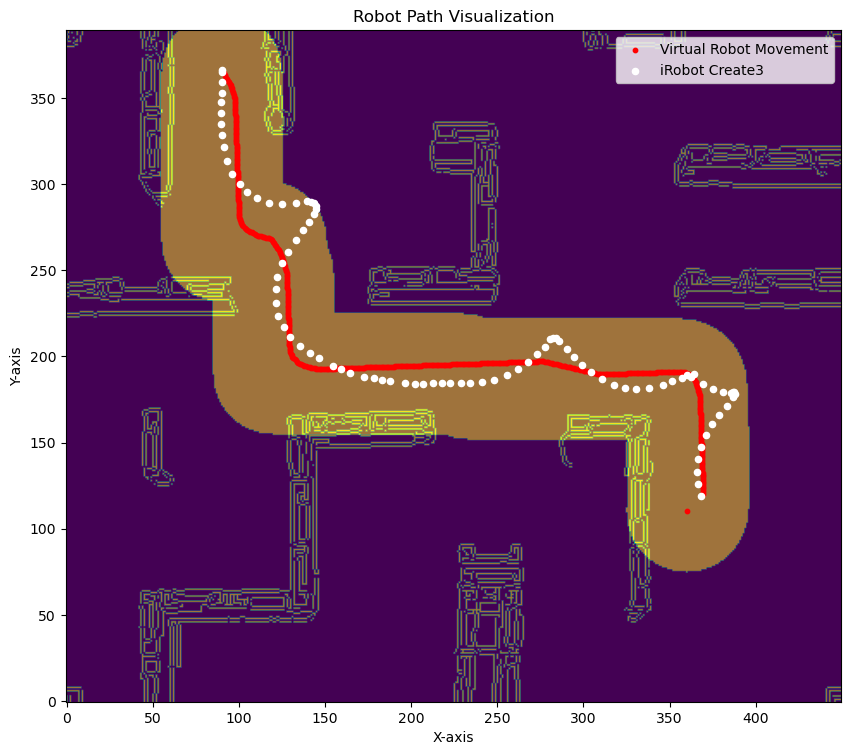

In [202]:
irobot_robot_movement = robot_movement_on_maze('robot_movement_round1.txt',start)
visualize_robot_path(maze_matrix,my_robot, irobot_robot_movement, fig_size=10)

In [204]:
%timeit is_within_astar_boundaries(my_robot, clean_full_path, distance=10, angle=my_robot.heading)

101 μs ± 2.49 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
